In [ ]:
# ===== CELL 1: Imports =====
!pip install scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    confusion_matrix, classification_report
)

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
# ===== CELL 2: Load Data (Google Colab + Google Drive ONLY) =====

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd

# ==========================
# CHANGE ONLY THIS PATH
# ==========================
BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/covariates')

print(f'Using base directory: {BASE_DIR}')

# Dataset files
ar_path = BASE_DIR / 'arkansas_full_dataset.csv'
ca_path = BASE_DIR / 'california_full_dataset.csv'

# Validate files exist
if not ar_path.exists():
    raise FileNotFoundError(f'Could not find: {ar_path}')

if not ca_path.exists():
    raise FileNotFoundError(f'Could not find: {ca_path}')

# Read directly from Google Drive
ar_raw = pd.read_csv(ar_path)
ca_raw = pd.read_csv(ca_path)

print(f'Arkansas loaded: {ar_raw.shape}')
print(f'California loaded: {ca_raw.shape}')

print('\nArkansas label distribution:')
print(ar_raw['crop_label'].value_counts().sort_index())

print('\nCalifornia label distribution:')
print(ca_raw['crop_label'].value_counts().sort_index())

Mounted at /content/drive
Using base directory: /content/drive/MyDrive/Colab Notebooks/covariates
Arkansas loaded: (3602, 443)
California loaded: (1111, 443)

Arkansas label distribution:
crop_label
0     624
1     122
2     342
3    2463
4      51
Name: count, dtype: int64

California label distribution:
crop_label
0    162
1     67
2    347
3     54
4     18
5    463
Name: count, dtype: int64


In [ ]:
# ===== CELL 3: Define Covariate Column Groups =====

CLIMATE_COLS = (
    [f'dewpoint_m{str(i).zfill(2)}' for i in range(1, 13)] +
    [f'precip_m{str(i).zfill(2)}'   for i in range(1, 13)] +
    [f'pressure_m{str(i).zfill(2)}' for i in range(1, 13)] +
    [f'temp_m{str(i).zfill(2)}'     for i in range(1, 13)] +
    [f'wind_u_m{str(i).zfill(2)}'   for i in range(1, 13)] +
    [f'wind_v_m{str(i).zfill(2)}'   for i in range(1, 13)]
)  # 72 features

SOIL_COLS = ['soil_bd', 'soil_clay', 'soil_oc', 'soil_ph', 'soil_sand']  # 5 features

TOPO_COLS = ['topo_aspect', 'topo_elevation', 'topo_slope', 'topo_tpi']  # 4 features

ALL_COV_COLS = CLIMATE_COLS + SOIL_COLS + TOPO_COLS  # 81 features

# Verify columns exist in dataset
for name, cols in [('Climate', CLIMATE_COLS), ('Soil', SOIL_COLS), ('Topo', TOPO_COLS)]:
    missing = [c for c in cols if c not in ar_raw.columns]
    print(f'{name}: {len(cols)} cols | Missing in AR: {len(missing)}')

print(f'\nTotal covariate features: {len(ALL_COV_COLS)}')

Climate: 72 cols | Missing in AR: 0
Soil: 5 cols | Missing in AR: 0
Topo: 4 cols | Missing in AR: 0

Total covariate features: 81


In [ ]:
# ===== CELL 4: Exploratory Analysis of Covariates =====

AR_NAMES = {0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton', 4: 'Others'}
CA_NAMES = {0: 'Grapes', 1: 'Rice', 2: 'Alfalfa', 3: 'Almonds', 4: 'Pistachios', 5: 'Others'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Analysis — Environmental Covariates (Arkansas)', fontsize=14, fontweight='bold')

# Temperature by class
ax = axes[0][0]
temp_cols = [f'temp_m{str(i).zfill(2)}' for i in range(1, 13)]
months = range(1, 13)
for cls in sorted(ar_raw['crop_label'].unique()):
    subset = ar_raw[ar_raw['crop_label'] == cls]
    mean_temp = subset[temp_cols].mean().values
    ax.plot(months, mean_temp, label=AR_NAMES[cls], marker='o', markersize=4)
ax.set_title('Mean Monthly Temperature by Crop')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (K)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Precipitation by class
ax = axes[0][1]
precip_cols = [f'precip_m{str(i).zfill(2)}' for i in range(1, 13)]
for cls in sorted(ar_raw['crop_label'].unique()):
    subset = ar_raw[ar_raw['crop_label'] == cls]
    mean_precip = subset[precip_cols].mean().values
    ax.plot(months, mean_precip, label=AR_NAMES[cls], marker='s', markersize=4)
ax.set_title('Mean Monthly Precipitation by Crop')
ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Soil properties boxplot
ax = axes[0][2]
soil_data = [ar_raw[ar_raw['crop_label'] == cls]['soil_oc'].dropna().values
             for cls in sorted(ar_raw['crop_label'].unique())]
bp = ax.boxplot(soil_data, labels=[AR_NAMES[c] for c in sorted(ar_raw['crop_label'].unique())],
                patch_artist=True)
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Soil Organic Carbon by Crop Class')
ax.set_ylabel('Organic Carbon')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3)

# Elevation by class
ax = axes[1][0]
elev_data = [ar_raw[ar_raw['crop_label'] == cls]['topo_elevation'].dropna().values
             for cls in sorted(ar_raw['crop_label'].unique())]
bp = ax.boxplot(elev_data, labels=[AR_NAMES[c] for c in sorted(ar_raw['crop_label'].unique())],
                patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Elevation by Crop Class')
ax.set_ylabel('Elevation (m)')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3)

# Correlation heatmap — soil + topo
ax = axes[1][1]
sample_cols = SOIL_COLS + TOPO_COLS
corr = ar_raw[sample_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar=False, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Correlation: Soil & Topo Features')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

# Class distribution
ax = axes[1][2]
for i, (df, names, state) in enumerate([(ar_raw, AR_NAMES, 'Arkansas')]):
    counts = df['crop_label'].value_counts().sort_index()
    bars = ax.bar([names[c] for c in counts.index], counts.values,
                  color=colors[:len(counts)])
    ax.bar_label(bars, fmt='%d', fontsize=9)
ax.set_title('Class Distribution — Arkansas')
ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_covariates.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

In [ ]:
# ===== CELL 5: MCTNet Architecture (Exact from Part 1 — unchanged) =====

class ECA(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


class ALPE(nn.Module):
    def __init__(self, T=36, d_model=32, kernel_size=3):
        super().__init__()
        self.T       = T
        self.d_model = d_model
        self.conv    = nn.Conv1d(d_model, d_model,
                                 kernel_size=kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.bn      = nn.BatchNorm1d(d_model)
        self.eca     = ECA(d_model)

    def _sinusoidal_pe(self, T, d_model, device):
        pe       = torch.zeros(T, d_model, device=device)
        position = torch.arange(0, T, device=device).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2, device=device).float()
            * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        return pe

    def forward(self, mask):
        B, T   = mask.shape
        device = mask.device
        pe = self._sinusoidal_pe(T, self.d_model, device)
        pe = pe.unsqueeze(0).expand(B, -1, -1)
        mask_exp  = mask.unsqueeze(-1).expand_as(pe)
        pe_masked = pe * mask_exp
        pe_t   = pe_masked.transpose(1, 2)
        pe_t   = self.conv(pe_t)
        pe_t   = self.bn(pe_t)
        pe_t   = self.eca(pe_t)
        return pe_t.transpose(1, 2)


class CNNSubModule(nn.Module):
    def __init__(self, d_model=30, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=kernel_size,
                               padding=kernel_size // 2, bias=False)
        self.bn1   = nn.BatchNorm1d(d_model)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=kernel_size,
                               padding=kernel_size // 2, bias=False)
        self.bn2   = nn.BatchNorm1d(d_model)
        self.relu  = nn.ReLU()

    def forward(self, x):
        residual = x.transpose(1, 2)
        out      = self.bn1(self.conv1(residual))
        out      = self.bn2(self.conv2(out))
        out      = self.relu(out + residual)
        return out.transpose(1, 2)


class TransformerSubModule(nn.Module):
    def __init__(self, d_model=30, n_head=5, use_alpe=False, T=36):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(T=T, d_model=d_model)
        self.attn    = nn.MultiheadAttention(d_model, n_head, batch_first=True, dropout=0.1)
        self.norm1   = nn.LayerNorm(d_model)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.ReLU(), nn.Linear(d_model * 2, d_model)
        )
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = x + self.alpe(mask)
        key_padding_mask = (mask == 0) if mask is not None else None
        attn_out, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class CTFusion(nn.Module):
    def __init__(self, d_model=30, n_head=5, kernel_size=3, use_alpe=False, T=36):
        super().__init__()
        self.cnn         = CNNSubModule(d_model, kernel_size)
        self.transformer = TransformerSubModule(d_model, n_head, use_alpe=use_alpe, T=T)
        self.pool        = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        cnn_out   = self.cnn(x)
        trans_out = self.transformer(x, mask)
        fused     = (cnn_out + trans_out).transpose(1, 2)
        return self.pool(fused).transpose(1, 2)


class MCTNet(nn.Module):
    """
    Original MCTNet — Sentinel-2 only (baseline).
    Input: x [B,36,10] + mask [B,36]
    """
    def __init__(self, n_classes, T=36, d_model=30, n_stage=3, n_head=5, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Linear(10, d_model)
        self.stages     = nn.ModuleList()
        current_T = T
        for i in range(n_stage):
            self.stages.append(CTFusion(d_model, n_head, kernel_size,
                                        use_alpe=(i == 0), T=current_T))
            current_T //= 2
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x, mask, cov=None):
        # cov ignored — kept for unified interface
        x = self.input_proj(x)
        current_mask = mask
        for i, stage in enumerate(self.stages):
            if i == 0:
                x = stage(x, current_mask)
                current_mask = F.max_pool1d(
                    current_mask.unsqueeze(1), kernel_size=2, stride=2
                ).squeeze(1)
                current_mask = (current_mask > 0).float()
            else:
                x = stage(x, None)
        x, _ = x.max(dim=1)
        return self.classifier(x)


print('MCTNet architecture defined.')
n_params = sum(p.numel() for p in MCTNet(5).parameters())
print(f'Parameters (baseline): {n_params:,}')

MCTNet architecture defined.
Parameters (baseline): 42,398


In [ ]:
# ===== CELL 6: MCTNet + Covariates (Extended Architecture) =====
# Only the classifier head is extended — MCTNet backbone is UNCHANGED
# Covariates are concatenated to the global pooled features before classification

class MCTNetCov(nn.Module):
    """
    MCTNet extended with static environmental covariates.

    The MCTNet backbone (ALPE + CTFusion × 3) is IDENTICAL to Part 1.
    After global max pool → concatenate covariate vector → classify.

    This keeps the temporal modeling completely unchanged.
    Only the final classification step uses extra information.
    """
    def __init__(self, n_classes, n_cov_features, T=36, d_model=30,
                 n_stage=3, n_head=5, kernel_size=3):
        super().__init__()

        # ── Identical MCTNet backbone ──
        self.input_proj = nn.Linear(10, d_model)
        self.stages     = nn.ModuleList()
        current_T = T
        for i in range(n_stage):
            self.stages.append(CTFusion(d_model, n_head, kernel_size,
                                        use_alpe=(i == 0), T=current_T))
            current_T //= 2

        # ── Covariate branch: small MLP to embed static features ──
        self.cov_mlp = nn.Sequential(
            nn.Linear(n_cov_features, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16)
        )

        # ── Fusion classifier ──
        # d_model (from backbone) + 16 (from cov_mlp)
        self.classifier = nn.Linear(d_model + 16, n_classes)

    def forward(self, x, mask, cov):
        """
        x    [B, 36, 10]  — spectral time series
        mask [B, 36]      — valid observation mask
        cov  [B, n_cov]   — static covariate vector
        """
        # ── MCTNet backbone (unchanged) ──
        x = self.input_proj(x)
        current_mask = mask
        for i, stage in enumerate(self.stages):
            if i == 0:
                x = stage(x, current_mask)
                current_mask = F.max_pool1d(
                    current_mask.unsqueeze(1), kernel_size=2, stride=2
                ).squeeze(1)
                current_mask = (current_mask > 0).float()
            else:
                x = stage(x, None)
        x, _ = x.max(dim=1)          # [B, d_model]

        # ── Covariate embedding ──
        cov_emb = self.cov_mlp(cov)  # [B, 16]

        # ── Fusion + classification ──
        fused = torch.cat([x, cov_emb], dim=1)   # [B, d_model + 16]
        return self.classifier(fused)


print('MCTNetCov architecture defined.')
for n_cov in [72, 5, 4, 81]:
    m = MCTNetCov(5, n_cov)
    p = sum(p.numel() for p in m.parameters())
    print(f'  n_cov={n_cov:3d} → Parameters: {p:,}')

MCTNetCov architecture defined.
  n_cov= 72 → Parameters: 45,342
  n_cov=  5 → Parameters: 43,198
  n_cov=  4 → Parameters: 43,166
  n_cov= 81 → Parameters: 45,630


In [ ]:

# ===== Enhanced Hybrid Architecture V2 =====
class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch, hidden=128):
        super().__init__()
        ks=[3,5,9]
        self.branches=nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_ch, hidden//len(ks), k, padding=k//2),
                nn.BatchNorm1d(hidden//len(ks)),
                nn.GELU(),
                nn.Conv1d(hidden//len(ks), hidden//len(ks), k, padding=k//2),
                nn.GELU()
            ) for k in ks
        ])
        self.se=nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(hidden, hidden//8,1),
            nn.GELU(),
            nn.Conv1d(hidden//8, hidden,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        feats=torch.cat([b(x) for b in self.branches], dim=1)
        return feats * self.se(feats)

class EnhancedMCTNetCov(nn.Module):
    def __init__(self, input_dim, cov_dim, num_classes, d_model=128, nhead=8):
        super().__init__()
        self.cnn=MultiScaleCNN(input_dim,d_model)
        self.proj=nn.Linear(input_dim,d_model)
        enc=nn.TransformerEncoderLayer(
            d_model=d_model,nhead=nhead,dim_feedforward=4*d_model,
            dropout=0.2,batch_first=True,activation='gelu',norm_first=True)
        self.transformer=nn.TransformerEncoder(enc,num_layers=4)
        self.pos=nn.Parameter(torch.randn(1,500,d_model)*0.02)
        self.gate=nn.Sequential(nn.Linear(d_model*2,d_model),nn.Sigmoid())
        self.head=nn.Sequential(
            nn.Linear(d_model+cov_dim,256),
            nn.GELU(),nn.Dropout(0.35),
            nn.Linear(256,128),nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(128,num_classes)
        )
    def forward(self,x,mask=None,cov=None):
        # x [B,T,F]
        xt=x.transpose(1,2)
        cnn=self.cnn(xt).mean(-1)
        t=self.proj(x)+self.pos[:,:x.size(1)]
        tr=self.transformer(t).mean(1)
        g=self.gate(torch.cat([cnn,tr],dim=-1))
        fused=g*cnn+(1-g)*tr
        if cov is not None:
            fused=torch.cat([fused,cov],dim=-1)
        return self.head(fused)


In [ ]:
# ===== CELL 7: Dataset Classes =====

class CropDatasetBase(Dataset):
    """Sentinel-2 only — for baseline MCTNet."""
    def __init__(self, X, mask, y):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], None, self.y[idx]


class CropDatasetCov(Dataset):
    """Sentinel-2 + covariates — for MCTNetCov."""
    def __init__(self, X, mask, cov, y):
        self.X    = torch.tensor(X,   dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.cov  = torch.tensor(cov,  dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.cov[idx], self.y[idx]


print('Dataset classes defined.')

Dataset classes defined.


In [ ]:
import re

# ===== CELL 8: Data Preparation Function =====

AR_NAMES = {0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton', 4: 'Others'}
CA_NAMES = {0: 'Grapes', 1: 'Rice', 2: 'Alfalfa', 3: 'Almonds', 4: 'Pistachios', 5: 'Others'}

def prepare_data_with_cov(df, cov_cols, label_col='crop_label',
                           class_names_map=None, state='Arkansas'):
    """
    Prepares train/val/test DataLoaders for one configuration.

    cov_cols: list of covariate column names to include.
              Pass [] for baseline (Sentinel-2 only).
    """
    print(f'\nPreparing {state} | Config: {len(cov_cols)} cov features...')

    # ── 1. Band columns ──
    band_cols = [c for c in df.columns if re.match(r'.+_t\d+$', c)]
    band_cols = sorted(band_cols, key=lambda x: int(re.search(r'_t(\d+)$', x).group(1)))
    print(f'  Band cols: {len(band_cols)}')

    # ── 2. Build X [N, 36, 10] ──
    X = df[band_cols].values.astype(np.float32).reshape(-1, 36, 10)

    # ── 3. Mask (infer from zeros if no mask columns) ──
    mask = (X.sum(axis=2) != 0).astype(np.float32)

    # ── 4. Normalize X ──
    X_flat = X.reshape(-1, 10)
    X_mean = X_flat.mean(axis=0)
    X_std  = X_flat.std(axis=0) + 1e-8
    X = (X - X_mean) / X_std

    # ── 5. Covariates ──
    has_cov = len(cov_cols) > 0
    if has_cov:
        missing = [c for c in cov_cols if c not in df.columns]
        if missing:
            print(f'  WARNING: {len(missing)} cov cols missing in dataframe!')
        available = [c for c in cov_cols if c in df.columns]
        cov = df[available].values.astype(np.float32)
        # Normalize covariates
        cov_mean = cov.mean(axis=0)
        cov_std  = cov.std(axis=0) + 1e-8
        cov = (cov - cov_mean) / cov_std
    else:
        cov = np.zeros((len(df), 1), dtype=np.float32)  # dummy

    # ── 6. Labels ──
    y = df[label_col].values.astype(np.int64)
    n_classes = len(np.unique(y))

    if class_names_map is not None:
        class_names = [class_names_map[c] for c in sorted(np.unique(y))]
    else:
        class_names = [str(c) for c in sorted(np.unique(y))]

    # ── 7. Split ──
    X_train, X_temp, y_train, y_temp, m_train, m_temp, c_train, c_temp = train_test_split(
        X, y, mask, cov, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test, m_val, m_test, c_val, c_test = train_test_split(
        X_temp, y_temp, m_temp, c_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    # ── 8. Loaders ──
    def make_loader(X, m, c, y, shuffle):
        if has_cov:
            ds = CropDatasetCov(X, m, c, y)
        else:
            ds = CropDatasetBase(X, m, y)
        return DataLoader(ds, batch_size=32, shuffle=shuffle, num_workers=0, collate_fn=collate_fn)

    train_loader = make_loader(X_train, m_train, c_train, y_train, True)
    val_loader   = make_loader(X_val,   m_val,   c_val,   y_val,   False)
    test_loader  = make_loader(X_test,  m_test,  c_test,  y_test,  False)

    n_cov = len(cov_cols) if has_cov else 0
    print(f'  Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
    print(f'  Classes ({n_classes}): {class_names}')

    return train_loader, val_loader, test_loader, n_classes, class_names, n_cov


print('Data preparation function ready.')

Data preparation function ready.


In [ ]:
# ===== CELL 9: Training Functions =====

def collate_fn(batch):
    """Handle None covariates in baseline mode."""
    Xs, masks, covs, ys = zip(*batch)
    X_t    = torch.stack(Xs)
    mask_t = torch.stack(masks)
    y_t    = torch.stack(ys)
    if covs[0] is None:
        cov_t = None
    else:
        cov_t = torch.stack(covs)
    return X_t, mask_t, cov_t, y_t


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for batch in loader:
        X, mask, cov, y = batch
        X    = X.to(device)
        mask = mask.to(device)
        cov  = cov.to(device) if cov is not None else None
        y    = y.to(device)

        optimizer.zero_grad()
        out  = model(X, mask, cov)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds, all_trues = [], []
    total_loss = 0.0
    criterion  = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            X, mask, cov, y = batch
            X    = X.to(device)
            mask = mask.to(device)
            cov  = cov.to(device) if cov is not None else None
            y    = y.to(device)
            out  = model(X, mask, cov)
            total_loss += criterion(out, y).item()
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_trues.extend(y.cpu().numpy())
    return np.array(all_preds), np.array(all_trues), total_loss / len(loader)


def train_config(train_loader, val_loader, test_loader,
                 n_classes, class_names, n_cov,
                 config_name, n_epochs=100):
    """Train one ablation configuration."""
    print('\n' + '='*55)
    print(f'  Config: {config_name}')
    print('='*55)

    # Select model
    if n_cov == 0:
        model = MCTNet(n_classes=n_classes).to(device)
    else:
        model = MCTNetCov(n_classes=n_classes, n_cov_features=n_cov).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Parameters: {n_params:,}')

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=80, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_f1': []}

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_preds, val_trues, val_loss = evaluate(model, val_loader)
        scheduler.step()

        val_oa = accuracy_score(val_trues, val_preds)
        val_f1 = f1_score(val_trues, val_preds, average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_oa'].append(val_oa)
        history['val_f1'].append(val_f1)

        if epoch % 20 == 0:
            print(f'  Ep {epoch:3d}/{n_epochs} | '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Val OA: {val_oa:.4f} | Val F1: {val_f1:.4f}')

    # Final test
    test_preds, test_trues, _ = evaluate(model, test_loader)
    oa    = accuracy_score(test_trues, test_preds)
    kappa = cohen_kappa_score(test_trues, test_preds)
    f1    = f1_score(test_trues, test_preds, average='macro', zero_division=0)

    print(f'\n  ── TEST RESULTS ──')
    print(f'  OA={oa:.4f} | Kappa={kappa:.4f} | F1={f1:.4f}')
    print(classification_report(test_trues, test_preds,
                                 target_names=class_names, zero_division=0))

    return model, history, test_preds, test_trues, (oa, kappa, f1)


print('Training functions ready.')

Training functions ready.


In [ ]:
# ===== CELL 10: Arkansas Ablation Study =====

CONFIGS = [
    ('Sentinel-2 only',          []),
    ('Sentinel-2 + Climate',     CLIMATE_COLS),
    ('Sentinel-2 + Soil',        SOIL_COLS),
    ('Sentinel-2 + Topography',  TOPO_COLS),
    ('Sentinel-2 + All',         ALL_COV_COLS),
]

ar_results = {}

for config_name, cov_cols in CONFIGS:
    # Prepare data
    tr, va, te, nc, cn, n_cov = prepare_data_with_cov(
        ar_raw, cov_cols, class_names_map=AR_NAMES, state='Arkansas'
    )

    # Train
    model, hist, preds, trues, metrics = train_config(
        tr, va, te, nc, cn, n_cov,
        config_name=f'AR | {config_name}',
        n_epochs=100
    )

    ar_results[config_name] = {
        'metrics': metrics,
        'history': hist,
        'preds':   preds,
        'trues':   trues,
        'classes': cn
    }

print('\n✓ Arkansas ablation study complete.')


Preparing Arkansas | Config: 0 cov features...
  Band cols: 360
  Train: 2521 | Val: 540 | Test: 541
  Classes (5): ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

  Config: AR | Sentinel-2 only
  Parameters: 42,398
  Ep  20/100 | Train Loss: 0.0104 | Val OA: 0.9815 | Val F1: 0.9071
  Ep  40/100 | Train Loss: 0.0003 | Val OA: 0.9852 | Val F1: 0.9179
  Ep  60/100 | Train Loss: 0.0001 | Val OA: 0.9870 | Val F1: 0.9380
  Ep  80/100 | Train Loss: 0.0045 | Val OA: 0.9833 | Val F1: 0.9188
  Ep 100/100 | Train Loss: 0.0003 | Val OA: 0.9907 | Val F1: 0.9459

  ── TEST RESULTS ──
  OA=0.9797 | Kappa=0.9584 | F1=0.8584
              precision    recall  f1-score   support

    Soybeans       0.98      1.00      0.99        94
        Rice       1.00      0.94      0.97        18
        Corn       0.98      0.98      0.98        52
      Cotton       0.98      0.99      0.99       370
      Others       0.50      0.29      0.36         7

    accuracy                           0.98       541


In [ ]:
# ===== CELL 11: California Ablation Study =====

ca_results = {}

for config_name, cov_cols in CONFIGS:
    tr, va, te, nc, cn, n_cov = prepare_data_with_cov(
        ca_raw, cov_cols, class_names_map=CA_NAMES, state='California'
    )

    model, hist, preds, trues, metrics = train_config(
        tr, va, te, nc, cn, n_cov,
        config_name=f'CA | {config_name}',
        n_epochs=200
    )

    ca_results[config_name] = {
        'metrics': metrics,
        'history': hist,
        'preds':   preds,
        'trues':   trues,
        'classes': cn
    }

print('\n✓ California ablation study complete.')


Preparing California | Config: 0 cov features...
  Band cols: 360
  Train: 777 | Val: 167 | Test: 167
  Classes (6): ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

  Config: CA | Sentinel-2 only
  Parameters: 42,429
  Ep  20/200 | Train Loss: 0.0970 | Val OA: 0.8503 | Val F1: 0.8373
  Ep  40/200 | Train Loss: 0.0135 | Val OA: 0.8503 | Val F1: 0.7840
  Ep  60/200 | Train Loss: 0.0044 | Val OA: 0.8323 | Val F1: 0.7675
  Ep  80/200 | Train Loss: 0.0017 | Val OA: 0.8323 | Val F1: 0.7757
  Ep 100/200 | Train Loss: 0.0009 | Val OA: 0.8503 | Val F1: 0.7883
  Ep 120/200 | Train Loss: 0.0008 | Val OA: 0.8443 | Val F1: 0.7856
  Ep 140/200 | Train Loss: 0.0010 | Val OA: 0.8443 | Val F1: 0.8297
  Ep 160/200 | Train Loss: 0.0005 | Val OA: 0.8503 | Val F1: 0.8204
  Ep 180/200 | Train Loss: 0.0004 | Val OA: 0.8383 | Val F1: 0.8099
  Ep 200/200 | Train Loss: 0.0007 | Val OA: 0.8443 | Val F1: 0.8235

  ── TEST RESULTS ──
  OA=0.8743 | Kappa=0.8231 | F1=0.8358
              precision

In [ ]:
# ===== CELL 12: Ablation Study Results Table =====

print('\n' + '='*75)
print('ABLATION STUDY RESULTS')
print('='*75)
print(f'{"Configuration":<30} {"OA":>7} {"Kappa":>7} {"F1":>7}')
print('-'*75)

print('\n── ARKANSAS ──')
for config_name, _ in CONFIGS:
    oa, kappa, f1 = ar_results[config_name]['metrics']
    print(f'  {config_name:<28} {oa:>7.4f} {kappa:>7.4f} {f1:>7.4f}')

print('\n── CALIFORNIA ──')
for config_name, _ in CONFIGS:
    oa, kappa, f1 = ca_results[config_name]['metrics']
    print(f'  {config_name:<28} {oa:>7.4f} {kappa:>7.4f} {f1:>7.4f}')

print('='*75)


ABLATION STUDY RESULTS
Configuration                       OA   Kappa      F1
---------------------------------------------------------------------------

── ARKANSAS ──
  Sentinel-2 only               0.9797  0.9584  0.8584
  Sentinel-2 + Climate          0.9871  0.9735  0.8954
  Sentinel-2 + Soil             0.9871  0.9735  0.8991
  Sentinel-2 + Topography       0.9871  0.9734  0.9033
  Sentinel-2 + All              0.9908  0.9811  0.9070

── CALIFORNIA ──
  Sentinel-2 only               0.8743  0.8231  0.8358
  Sentinel-2 + Climate          0.8922  0.8466  0.8242
  Sentinel-2 + Soil             0.8743  0.8245  0.8328
  Sentinel-2 + Topography       0.8802  0.8318  0.8366
  Sentinel-2 + All              0.8982  0.8563  0.8705


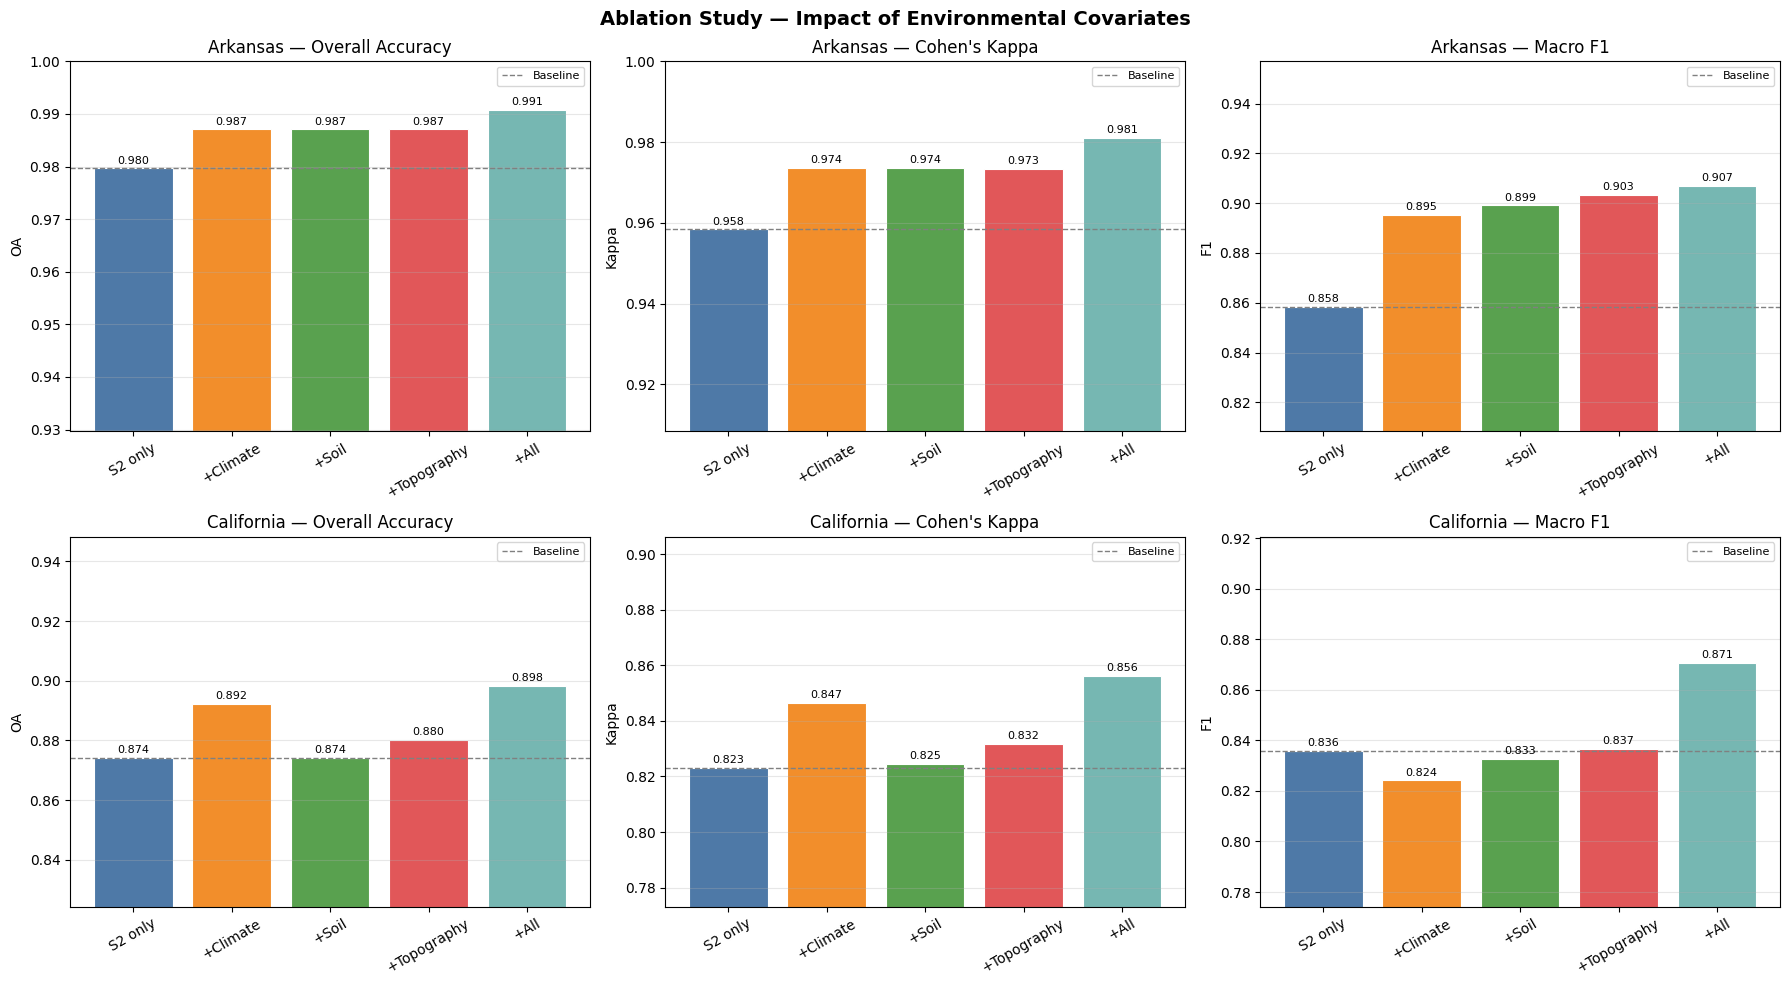

Saved: ablation_results.png


In [ ]:
# ===== CELL 13: Ablation Comparison Plot =====

config_labels = [name.replace('Sentinel-2 + ', '+').replace('Sentinel-2 only', 'S2 only')
                 for name, _ in CONFIGS]
colors_bar = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Ablation Study — Impact of Environmental Covariates', fontsize=14, fontweight='bold')

for row, (state, results) in enumerate([('Arkansas', ar_results), ('California', ca_results)]):
    oas    = [results[n]['metrics'][0] for n, _ in CONFIGS]
    kappas = [results[n]['metrics'][1] for n, _ in CONFIGS]
    f1s    = [results[n]['metrics'][2] for n, _ in CONFIGS]

    # OA bars
    ax = axes[row][0]
    bars = ax.bar(config_labels, oas, color=colors_bar, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title(f'{state} — Overall Accuracy')
    ax.set_ylim(max(0, min(oas) - 0.05), min(1.0, max(oas) + 0.05))
    ax.set_ylabel('OA')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=oas[0], color='gray', linestyle='--', linewidth=1, label='Baseline')
    ax.legend(fontsize=8)

    # Kappa bars
    ax = axes[row][1]
    bars = ax.bar(config_labels, kappas, color=colors_bar, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title(f'{state} — Cohen\'s Kappa')
    ax.set_ylim(max(0, min(kappas) - 0.05), min(1.0, max(kappas) + 0.05))
    ax.set_ylabel('Kappa')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=kappas[0], color='gray', linestyle='--', linewidth=1, label='Baseline')
    ax.legend(fontsize=8)

    # F1 bars
    ax = axes[row][2]
    bars = ax.bar(config_labels, f1s, color=colors_bar, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title(f'{state} — Macro F1')
    ax.set_ylim(max(0, min(f1s) - 0.05), min(1.0, max(f1s) + 0.05))
    ax.set_ylabel('F1')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=f1s[0], color='gray', linestyle='--', linewidth=1, label='Baseline')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results.png')

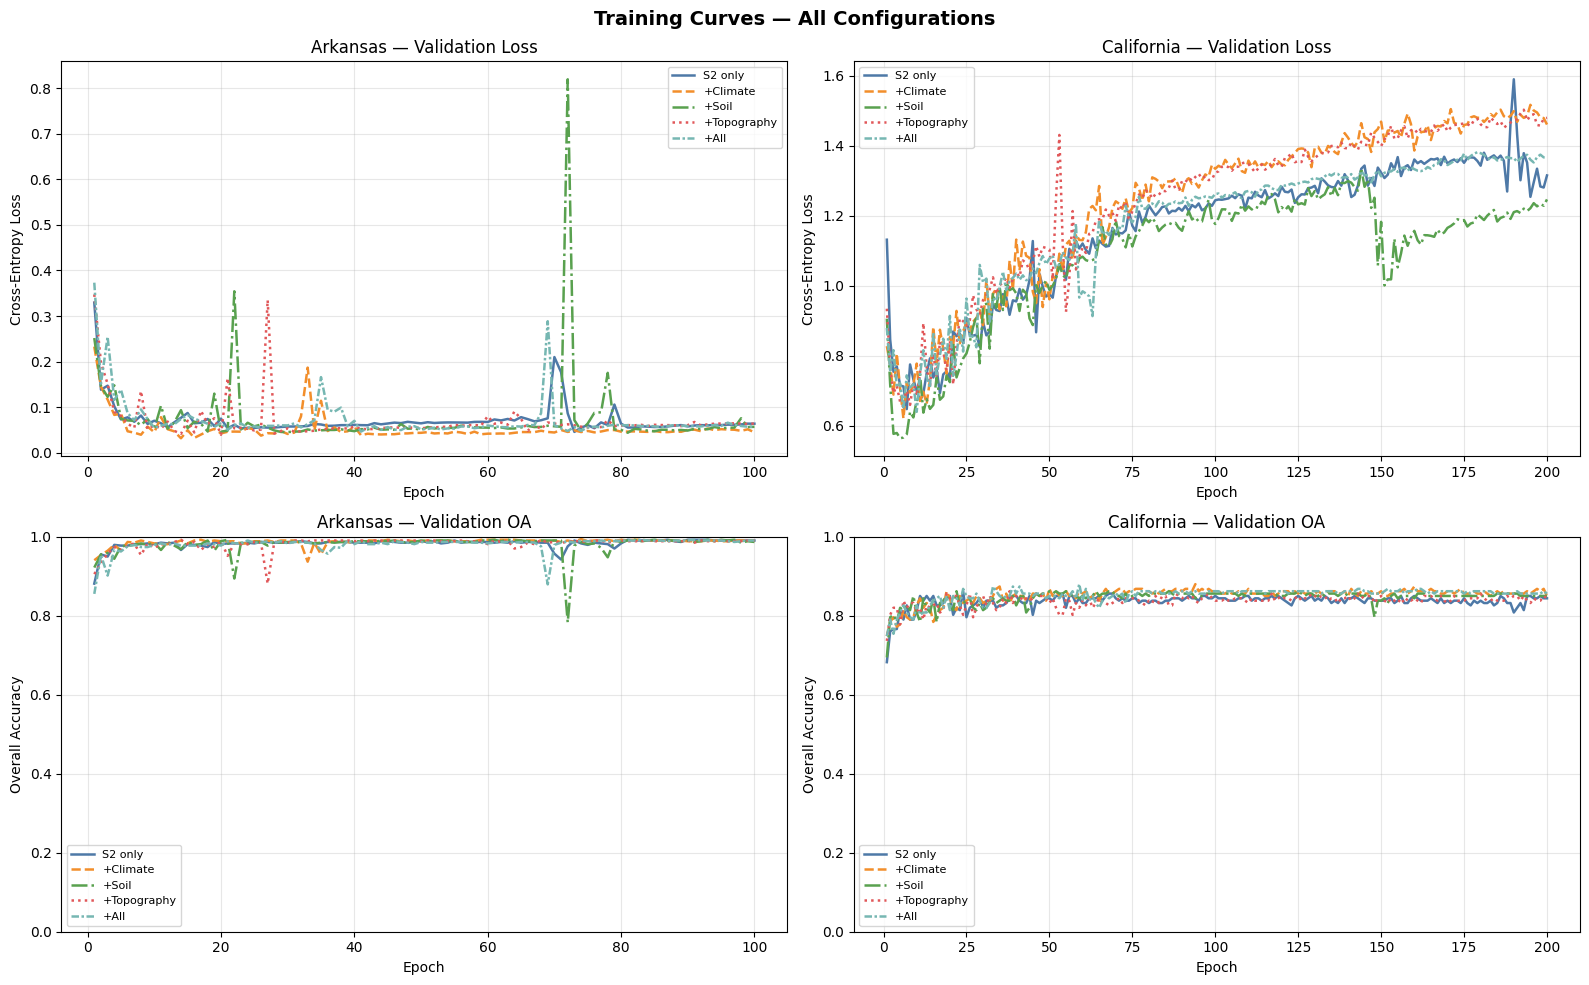

Saved: training_curves_ablation.png


In [ ]:
# ===== CELL 14: Training Curves (All Configs) =====

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Curves — All Configurations', fontsize=14, fontweight='bold')

line_styles = ['-', '--', '-.', ':', (0,(3,1,1,1))]
curve_colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

for col, (state, results) in enumerate([('Arkansas', ar_results), ('California', ca_results)]):
    for i, (config_name, _) in enumerate(CONFIGS):
        hist   = results[config_name]['history']
        epochs = range(1, len(hist['train_loss']) + 1)
        label  = config_name.replace('Sentinel-2 + ', '+').replace('Sentinel-2 only', 'S2 only')

        axes[0][col].plot(epochs, hist['val_loss'],
                          label=label, color=curve_colors[i],
                          linestyle=line_styles[i], linewidth=1.8)
        axes[1][col].plot(epochs, hist['val_oa'],
                          label=label, color=curve_colors[i],
                          linestyle=line_styles[i], linewidth=1.8)

    axes[0][col].set_title(f'{state} — Validation Loss')
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].set_ylabel('Cross-Entropy Loss')
    axes[0][col].legend(fontsize=8)
    axes[0][col].grid(True, alpha=0.3)

    axes[1][col].set_title(f'{state} — Validation OA')
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].set_ylabel('Overall Accuracy')
    axes[1][col].set_ylim(0, 1)
    axes[1][col].legend(fontsize=8)
    axes[1][col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_ablation.png')

Best AR config: Sentinel-2 + All
Best CA config: Sentinel-2 + All


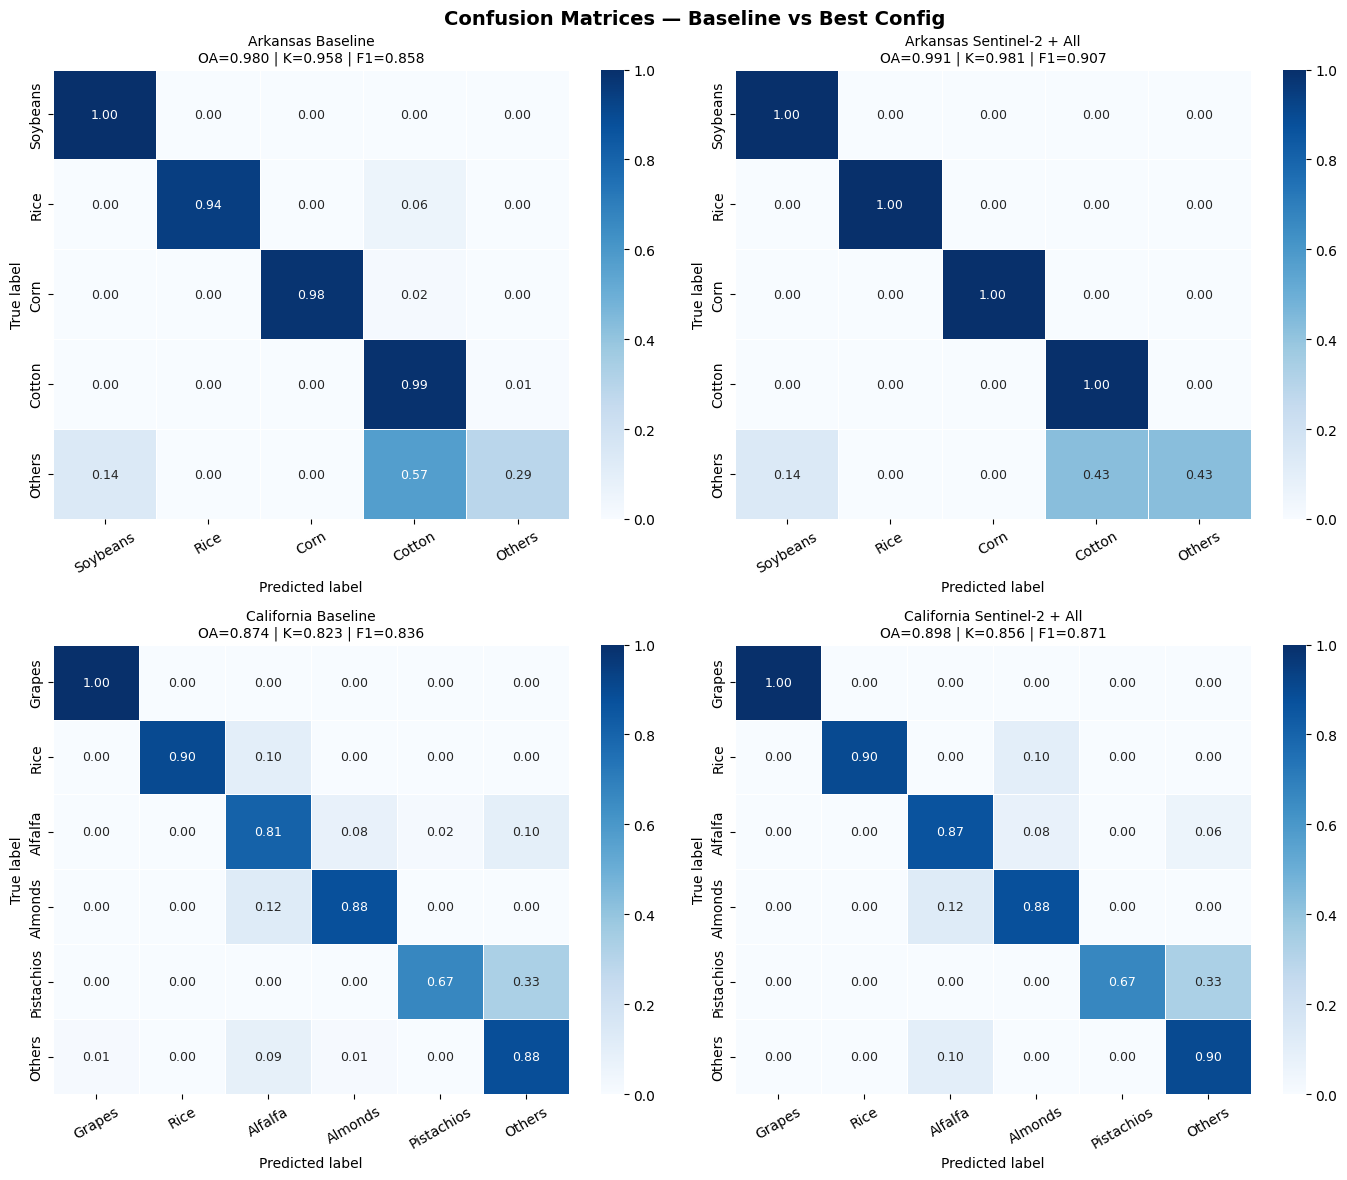

Saved: confusion_matrices_ablation.png


In [ ]:
# ===== CELL 15: Confusion Matrices — Best Configuration =====

def best_config(results):
    best = max(results, key=lambda k: results[k]['metrics'][2])  # by F1
    return best

ar_best = best_config(ar_results)
ca_best = best_config(ca_results)
print(f'Best AR config: {ar_best}')
print(f'Best CA config: {ca_best}')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices — Baseline vs Best Config', fontsize=14, fontweight='bold')

plot_configs = [
    (ar_results, 'Sentinel-2 only', 'Arkansas Baseline', axes[0][0]),
    (ar_results, ar_best,           f'Arkansas {ar_best}', axes[0][1]),
    (ca_results, 'Sentinel-2 only', 'California Baseline', axes[1][0]),
    (ca_results, ca_best,           f'California {ca_best}', axes[1][1]),
]

for results, config, title, ax in plot_configs:
    preds   = results[config]['preds']
    trues   = results[config]['trues']
    classes = results[config]['classes']
    cm = confusion_matrix(trues, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, linewidths=0.5, annot_kws={'size': 9})
    oa, kappa, f1 = results[config]['metrics']
    ax.set_title(f'{title}\nOA={oa:.3f} | K={kappa:.3f} | F1={f1:.3f}', fontsize=10)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrices_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_ablation.png')

In [ ]:
# ===== CELL 16: Final Summary =====

print('\n' + '='*70)
print('PART 2 FINAL SUMMARY — ABLATION STUDY')
print('='*70)

for state, results in [('ARKANSAS', ar_results), ('CALIFORNIA', ca_results)]:
    print(f'\n── {state} ──')
    baseline_oa = results['Sentinel-2 only']['metrics'][0]
    baseline_f1 = results['Sentinel-2 only']['metrics'][2]
    print(f'  Baseline (S2 only): OA={baseline_oa:.4f} | F1={baseline_f1:.4f}')
    print()
    for config_name, _ in CONFIGS[1:]:
        oa, kappa, f1 = results[config_name]['metrics']
        delta_oa = oa - baseline_oa
        delta_f1 = f1 - baseline_f1
        sign_oa  = '+' if delta_oa >= 0 else ''
        sign_f1  = '+' if delta_f1 >= 0 else ''
        print(f'  {config_name:<28} '
              f'OA={oa:.4f} ({sign_oa}{delta_oa:.4f}) | '
              f'F1={f1:.4f} ({sign_f1}{delta_f1:.4f})')

print('\n' + '='*70)
print('Plots saved:')
print('  ablation_results.png')
print('  training_curves_ablation.png')
print('  confusion_matrices_ablation.png')
print('  eda_covariates.png')
print('='*70)


PART 2 FINAL SUMMARY — ABLATION STUDY

── ARKANSAS ──
  Baseline (S2 only): OA=0.9797 | F1=0.8584

  Sentinel-2 + Climate         OA=0.9871 (+0.0074) | F1=0.8954 (+0.0370)
  Sentinel-2 + Soil            OA=0.9871 (+0.0074) | F1=0.8991 (+0.0407)
  Sentinel-2 + Topography      OA=0.9871 (+0.0074) | F1=0.9033 (+0.0449)
  Sentinel-2 + All             OA=0.9908 (+0.0111) | F1=0.9070 (+0.0486)

── CALIFORNIA ──
  Baseline (S2 only): OA=0.8743 | F1=0.8358

  Sentinel-2 + Climate         OA=0.8922 (+0.0180) | F1=0.8242 (-0.0117)
  Sentinel-2 + Soil            OA=0.8743 (+0.0000) | F1=0.8328 (-0.0031)
  Sentinel-2 + Topography      OA=0.8802 (+0.0060) | F1=0.8366 (+0.0007)
  Sentinel-2 + All             OA=0.8982 (+0.0240) | F1=0.8705 (+0.0347)

Plots saved:
  ablation_results.png
  training_curves_ablation.png
  confusion_matrices_ablation.png
  eda_covariates.png
